<a href="https://colab.research.google.com/github/notsamaltman/Synapse_LP/blob/week4/Copy_of_Synapse_LP_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 4**

## **DJS Synapse Learning Period**
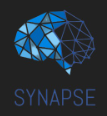

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Mounted at /content/drive


In [3]:
import pandas as pd

#import your dataset here
df = pd.read_csv('/content/drive/MyDrive/datasets/adult_income_dataset.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Dealing with Nan values

In [4]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [5]:
df.dropna()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

In [6]:
#Write your code here
# doubt here

## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [7]:
#write your code here
df.drop(axis=1, columns=['education-num', 'relationship'], inplace=True)

## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns (distinct values na), One Hot encode it**

In [8]:
#Write your code here
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
enc_one = OneHotEncoder(handle_unknown='ignore')
enc_label = LabelEncoder()


#Hint: Check which needs one hot encoding which needs label encoding
df['marital-status'] = enc_one.fit_transform(df[['marital-status']]).toarray()
for col in ['workclass', 'education', 'occupation', 'race', 'sex', 'native-country', 'income']:
    df[col] = enc_label.fit_transform(df[col])
#Then perform necessary transformations (Feel free to add more coding cells)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       32561 non-null  int64  
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  int64  
 4   marital-status  32561 non-null  float64
 5   occupation      32561 non-null  int64  
 6   race            32561 non-null  int64  
 7   sex             32561 non-null  int64  
 8   capital-gain    32561 non-null  int64  
 9   capital-loss    32561 non-null  int64  
 10  hours-per-week  32561 non-null  int64  
 11  native-country  32561 non-null  int64  
 12  income          32561 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 3.2 MB


## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [10]:
df['income'] = enc_label.fit_transform(df['income'])

**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [11]:
#write your code here
X = df.drop(axis=1, columns=['income'])
y = df['income']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

In [12]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression()
model_log.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Find the accuracy and confusion matrix for the same and explain what it shows.

In [13]:
model_log.score(X_test, y_test)
from sklearn.metrics import classification_report, confusion_matrix
y_pred_log = model_log.predict(X_test)
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[7036  329]
 [1714  690]]
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      7365
           1       0.68      0.29      0.40      2404

    accuracy                           0.79      9769
   macro avg       0.74      0.62      0.64      9769
weighted avg       0.77      0.79      0.76      9769



### Now that you have printed a confusion matrix and classification report. Let's see what you have understood from it. Write a short paragraph highlighting what you understoood from it below.

confusion matrix tells us the true +ve true -ve and false +ves and false -ves predicted by the model these statistics are then used in the classification report to give us metrics like precision recall f1-score which is the harmoning mean of precision and recall

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [14]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import BernoulliNB

model_nb = BernoulliNB()
model_nb.fit(X_train, y_train)
# Make predictions
y_predict_nb = model_nb.predict(X_test)

# Calculate accuracy
model_nb.score(X_test, y_test)

0.7890265124373017

# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [15]:
#import the decision tree from sklearn and run it on your data
from sklearn.tree import DecisionTreeClassifier

model_decision = DecisionTreeClassifier()
model_decision.fit(X_train, y_train)

DecisionTreeClassifier()

<b>Print the Model Accuracy</b>

In [16]:
model_decision.score(X_test, y_test)

0.7865697614904289

## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:in logistic regression Instead of predicting 0 or 1 directly, it predicts a probability between 0 and 1 using the sigmoid function.

naive baiyes is a Probabilistic model based on Bayes Theorem Naive because it assumes features are independent

decision tree splits the data by asking questions on features that give the most information gain.

### Mention some real life use cases for each of these three models:

Ans:

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

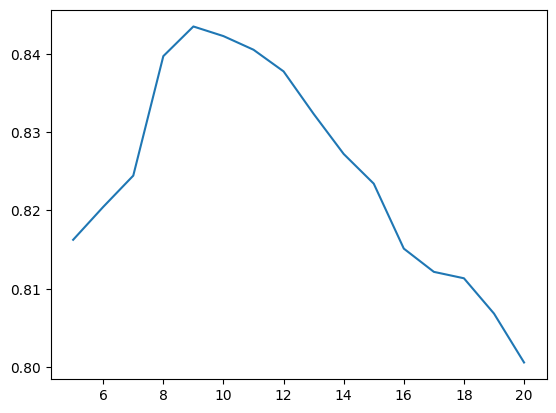

In [17]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)
accuracies = []
for k in range(5, 21, 1):
  model_decision = DecisionTreeClassifier(max_depth=k)
  model_decision.fit(X_train, y_train)
  accuracies.append(model_decision.score(X_test, y_test))
plt.plot(range(5, 21, 1), accuracies)

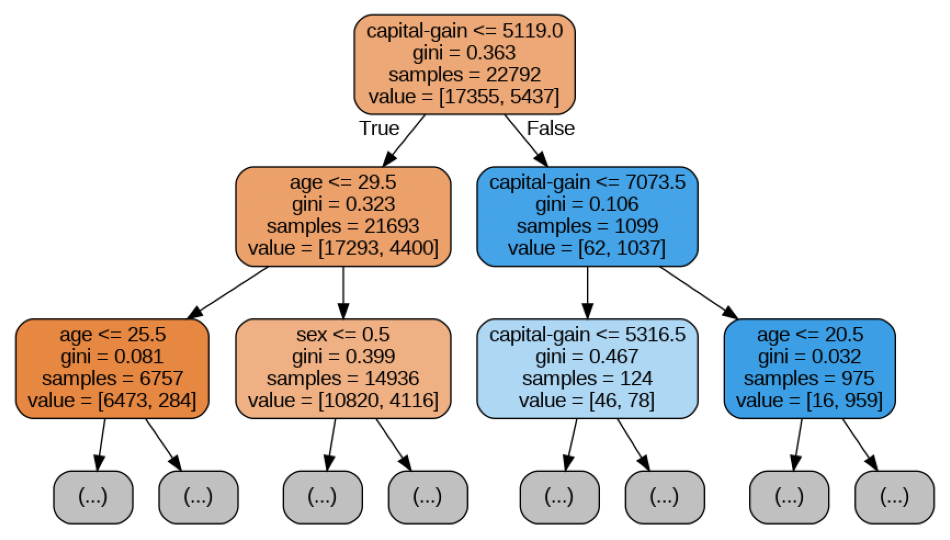

In [19]:
from sklearn import tree
import matplotlib.pyplot as plt
import graphviz

tree.export_graphviz(
    model_decision,
    out_file='tree.dot',
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2
)

!dot -Tpng tree.dot -o tree.png

image = plt.imread('tree.png')
plt.figure(figsize=(12, 12))
plt.imshow(image)
plt.axis('off')
plt.show()


### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:I changed max_depth in decision tree where even though the accuracy increased initially it slowly began decreasing with increasing depth

## SUPPORT VECTOR MACHINE (SVM)

Theory : https://www.youtube.com/watch?v=efR1C6CvhmE (Part 1)

Theory: https://www.youtube.com/watch?v=H9yACitf-KM

Maths Intuition : https://www.youtube.com/watch?v=Js3GLb1xPhc

EXTRAS:

https://www.youtube.com/watch?v=NDqACjz5j8g

If you are more curious and want to explore :

https://www.youtube.com/watch?v=Toet3EiSFcM (Part 2)

https://www.youtube.com/watch?v=efR1C6CvhmE&t=432s (Part 3)

https://www.youtube.com/watch?v=8bFKyb77vp0




In [20]:
#Now that we know SVM is sensitive to feature scales, so standardize (don't forget to standardise your X_test):
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [21]:
#Train your model
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train, y_train)

SVC()

In [23]:
#Predict and check accuracies
y_pred_svm = model_svm.predict(X_test)
model_svm.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


0.7539154468215785

In [ ]:
#let's try out using different kernels now. Freedom to choose lies in your hands. EXPLOREEE!


## BIAS AND VARIANCE
### Hurrayy! You have made it so far sane.

### Before moving forward let's first understand what exactly do you mean by bias and variance.

THEORY: https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/ (explained in quite detail do read this not just video)

VIDEO: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier


# Train the model


# Make predictions on the test data

# Evaluate the model's performance


# Optional: Generate a classification report for more details


In [ ]:
#find the accuracy


### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans :

In [ ]:
#write a code to implement BaggingClassifier


# Initialize the base estimator (e.g., Decision Tree)

# Initialize the BaggingClassifier


# Train the Bagging model

# Make predictions on the test data

# Evaluate the model's performance


# Optional: Generate a classification report for more details


### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans :

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [ ]:
#write code here

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

#yk the drill now


Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [ ]:
!pip install xgboost
import xgboost as xgb


### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.

Ans :

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans:








### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [ ]:
#implement pruning


In [ ]:
#before plotting a tree you will need to first convert your X_train and X_test to DataFrame (Explain WHY (Hint: You made one tree before and it worked fine so it has to do with something you did after..Explore))
#Code to convert it here:




In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique


<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

In [ ]:
#write your code here


# **RESEARCH TASK**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

# **End of Task**

> ©DJS Synapse 2025 - 2026